In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
from sklearn.preprocessing import LabelEncoder

# Null 처리 함수
def fillna(df):
    df['Age'].fillna(df['Age'].mean(),inplace=True)
    df['Cabin'].fillna('N',inplace=True)
    df['Embarked'].fillna('N',inplace=True)
    df['Fare'].fillna(0,inplace=True)
    return df

# 머신러닝 알고리즘에 불필요한 속성 제거
def drop_features(df):
    df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)
    return df

# 레이블 인코딩 수행. 
def format_features(df):
    df['Cabin'] = df['Cabin'].str[:1]
    features = ['Cabin','Sex','Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df

# 앞에서 설정한 Data Preprocessing 함수 호출
def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    return df


In [6]:
# 원본 데이터를 재로딩 하고, feature데이터 셋과 Label 데이터 셋 추출. 
titanic_df = pd.read_csv('/content/drive/MyDrive/대학원/ai-creator 공유폴더(기계학습기초_2022년2학기)/data/titanic_train.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df= titanic_df.drop('Survived',axis=1)

X_titanic_df = transform_features(X_titanic_df)

In [8]:
print(X_titanic_df.head())
print(y_titanic_df.head())

   Pclass  Sex   Age  SibSp  Parch     Fare  Cabin  Embarked
0       3    1  22.0      1      0   7.2500      7         3
1       1    0  38.0      1      0  71.2833      2         0
2       3    0  26.0      0      0   7.9250      7         3
3       1    0  35.0      1      0  53.1000      2         3
4       3    1  35.0      0      0   8.0500      7         3
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [9]:
def test_score(y_test, y_pred):
  print("accuracy: ", accuracy_score(y_test,y_pred))
  print("precision: ", precision_score(y_test,y_pred))
  print("recall: ", recall_score(y_test,y_pred))
  print("f1score: ", f1_score(y_test,y_pred))

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X_titanic_df, y_titanic_df, 
                                                    test_size=0.2, random_state=11)

# 분류기 생성, 하이퍼파라미터 추가
dt_clf = DecisionTreeClassifier(min_samples_split = 4 , random_state=156)

# 학습, 예측
dt_clf.fit(X_train, y_train)
y_pred = dt_clf.predict(X_test)

# 평가
test_score(y_test, y_pred)

accuracy:  0.8156424581005587
precision:  0.7333333333333333
recall:  0.7213114754098361
f1score:  0.7272727272727273


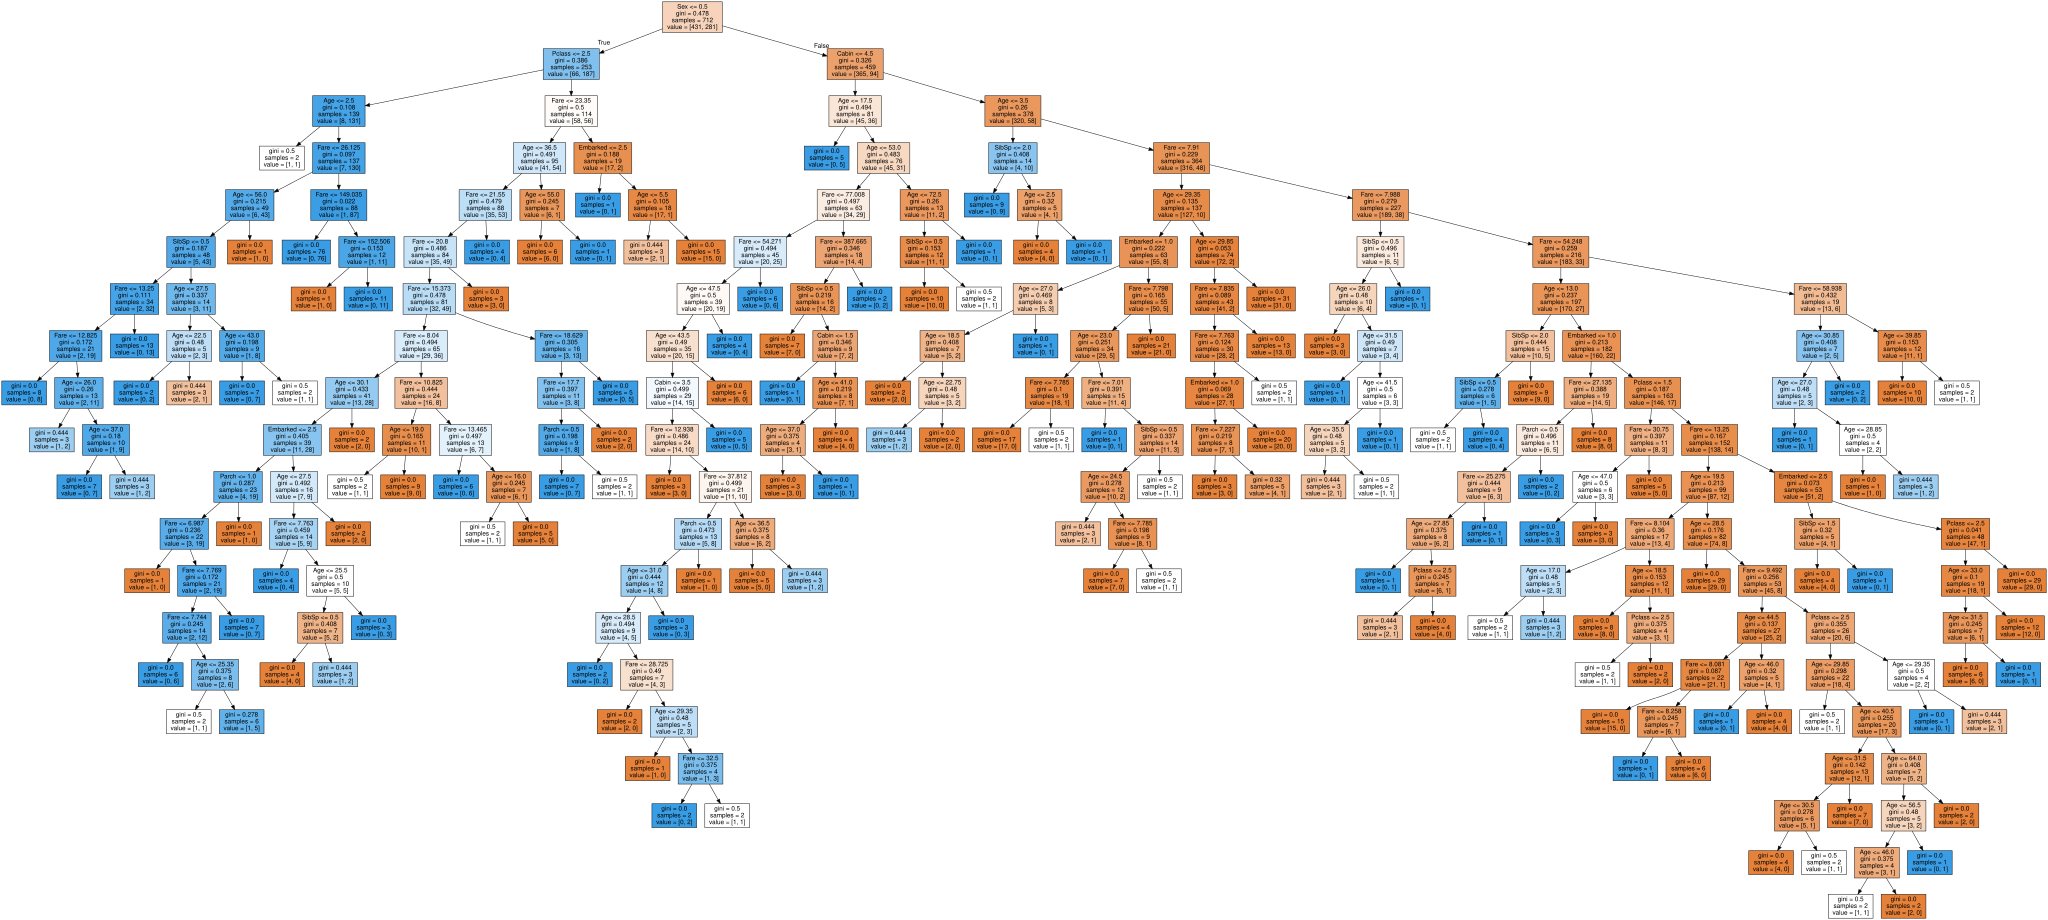

In [11]:
# 분류 내용 확인
from sklearn.tree import export_graphviz
import graphviz

export_graphviz(dt_clf, out_file='tree.dot',
                feature_names = X_titanic_df.columns, impurity=True, filled=True)

# 생성된 tree.dot 파일 시각화
with open("tree.dot") as f:
  dot_graph = f.read()

graphviz.Source(dot_graph)

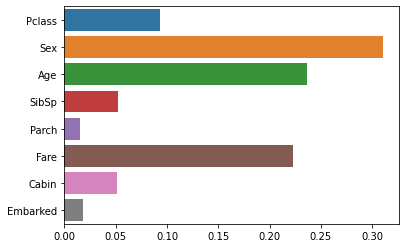

In [12]:
import seaborn as sns 
%matplotlib inline

# feature importance를 변수별로 시각화
sns.barplot(x=dt_clf.feature_importances_, y=X_titanic_df.columns)

In [14]:
import pandas as pd
from sklearn.model_selection import GridSearchCV

# 새로운 알고리즘생성(학습안된것)
dtree = DecisionTreeClassifier()

## 파라미터 설정
parameters = {'max_depth':[1,2,3,4], 'min_samples_split': [2,3,5] }
print(parameters)

# param_grid의 하이퍼 파라미터들을 3개 train, test set fold로 나눠서 테스트
## refit = True 가 default, 가장 좋은 파라미터 설정으로 재학습
grid_dtree = GridSearchCV(dtree, param_grid=parameters, cv=3, refit=True)

#붓꽃 Train 데이터로 param_grid 의 하이퍼파라미터들을 순차적으로 학습/평가
grid_dtree.fit(X_train, y_train)

# Grid SearchCV 결과 추출하여 DataFrame 로 변환
scores_df = pd.DataFrame(grid_dtree.cv_results_)
scores_df[['params','mean_test_score','rank_test_score',\
           'split0_test_score','split1_test_score','split2_test_score']]

{'max_depth': [1, 2, 3, 4], 'min_samples_split': [2, 3, 5]}


,params,mean_test_score,rank_test_score,split0_test_score,split1_test_score,split2_test_score
0,"{'max_depth': 1, 'min_samples_split': 2}",0.775319,7,0.747899,0.818565,0.759494
1,"{'max_depth': 1, 'min_samples_split': 3}",0.775319,7,0.747899,0.818565,0.759494
2,"{'max_depth': 1, 'min_samples_split': 5}",0.775319,7,0.747899,0.818565,0.759494
3,"{'max_depth': 2, 'min_samples_split': 2}",0.773907,10,0.752101,0.801688,0.767932
4,"{'max_depth': 2, 'min_samples_split': 3}",0.773907,10,0.752101,0.801688,0.767932
5,"{'max_depth': 2, 'min_samples_split': 5}",0.773907,10,0.752101,0.801688,0.767932
6,"{'max_depth': 3, 'min_samples_split': 2}",0.793574,1,0.768908,0.856540,0.755274
7,"{'max_depth': 3, 'min_samples_split': 3}",0.793574,1,0.768908,0.856540,0.755274
8,"{'max_depth': 3, 'min_samples_split': 5}",0.793574,1,0.768908,0.856540,0.755274
9,"{'max_depth': 4, 'min_samples_split': 2}",0.783741,5,0.760504,0.810127,0.780591


In [18]:
print('GridSearchCV 최적 파라미터 : ', grid_dtree.best_params_)
print('GridSearchCV 최고 정확도: {0:.4f}'.format(grid_dtree.best_score_))

GridSearchCV 최적 파라미터 :  {'max_depth': 3, 'min_samples_split': 2}
GridSearchCV 최고 정확도: 0.7936


In [19]:
# refit 된 estimator 반환
estimator = grid_dtree.best_estimator_

# 최적 하이퍼 파라미터로 학습됨.
pred = estimator.predict(X_test)
print('테스트 데이터 세트 정확도: {0:.4f}'.format(accuracy_score(y_test,pred)))

테스트 데이터 세트 정확도: 0.8715


In [20]:
estimator = grid_dtree.best_estimator_
print(estimator)

DecisionTreeClassifier(max_depth=3)


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_clf1 = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=8, \
                                 min_samples_split=8, random_state=0)
rf_clf1.fit(X_train, y_train)
pred = rf_clf1.predict(X_test)
print('예측 정확도: {0:.4f}'.format(accuracy_score(y_test , pred)))

예측 정확도: 0.8659


In [25]:
params = {
    'n_estimators':[30, 50, 70, 100],
    'max_depth' : [3, 4, 5, 6, 8, 10, 12], 
    'min_samples_leaf' : [3, 5, 8, 12, 18 ],
    'min_samples_split' : [3, 5, 8, 16, 20]
}
# RandomForestClassifier 객체 생성 후 GridSearchCV 수행
rf_clf = RandomForestClassifier(random_state=0, n_jobs=-1)
grid_cv = GridSearchCV(rf_clf , param_grid=params , cv=2, n_jobs=-1 )
grid_cv.fit(X_train , y_train)

print('최적 하이퍼 파라미터:\n', grid_cv.best_params_)
print('최고 예측 정확도: {0:.4f}'.format(grid_cv.best_score_))

최적 하이퍼 파라미터:
 {'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 16, 'n_estimators': 70}
최고 예측 정확도: 0.8146
